# Diabetes Prediction using Logistic regression

# Breast Cancer Prediction Project

Welcome to the Breast Cancer Prediction project! 🎯

In this beginner-friendly notebook, we'll walk through a step-by-step machine learning pipeline to predict whether a tumor is malignant or benign based on various features.

## Objective

Our goal is to build a machine learning model that can accurately predict whether a tumor is **malignant (M)** or **benign (B)** based on a set of measurements.

We'll use the dataset `Cancer_Data.csv` for this purpose.

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import os

## Step 1: Load the Dataset

In [3]:
file_path = 'Cancer_Data.csv'
if not os.path.exists(file_path):
    print(f"Error: {file_path} not found.")
    exit(1)

In [4]:
data = pd.read_csv(file_path)

## Step 2: Explore the Dataset

In [8]:
data.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Step 3: Clean the Data

In [9]:
# Drop 'id' column as it's not a useful feature
if 'id' in data.columns:
    data = data.drop('id', axis=1)

In [13]:
data.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [18]:
# Drop any columns with all NaN values (like an empty 'Unnamed: 32' if it exists)
data = data.dropna(axis=1, how='all')

In [16]:
# Handle missing values if any
data = data.dropna()

In [19]:
data.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 4: Visualize the Data

In [45]:
# Separate features (X) and target (y)
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

## Step 5: Preprocess the Data

In [21]:
# Encode target labels ('M' = 1, 'B' = 0)
le = LabelEncoder()
y = le.fit_transform(y)

C:\Users\mohit\AppData\Local\Temp\ipykernel_13660\2934361011.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='diagnosis', palette='Set2')


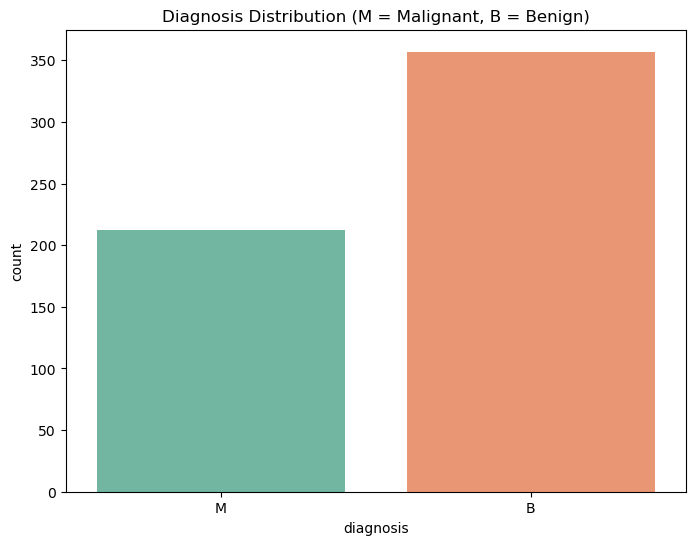

In [32]:
# Plot count of Diagnosis
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='diagnosis', palette='Set2')
plt.title('Diagnosis Distribution (M = Malignant, B = Benign)')
plt.savefig('diagnosis_count.png', bbox_inches='tight')
plt.show()

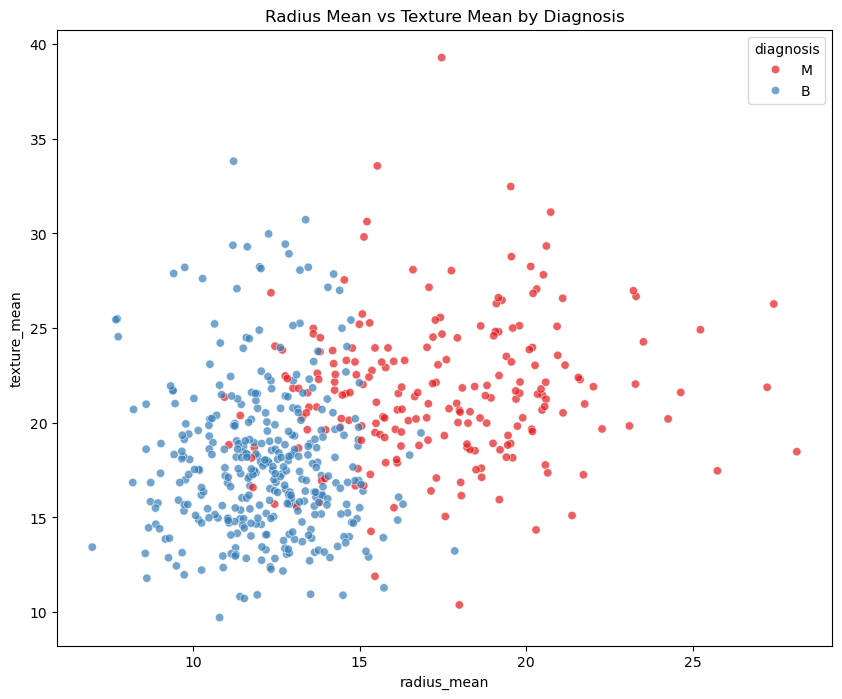

In [35]:
# Scatter plot for Radius Mean vs Texture Mean colored by Diagnosis
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='radius_mean', y='texture_mean', hue='diagnosis', palette='Set1', alpha=0.7)
plt.title('Radius Mean vs Texture Mean by Diagnosis')
plt.savefig('scatter_plot.png', bbox_inches='tight')
plt.show()

In [22]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 6: Train a Machine Learning Model

In [23]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [24]:
# Make predictions
y_pred = model.predict(X_test)

## Step 7: Evaluate the Model

In [25]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

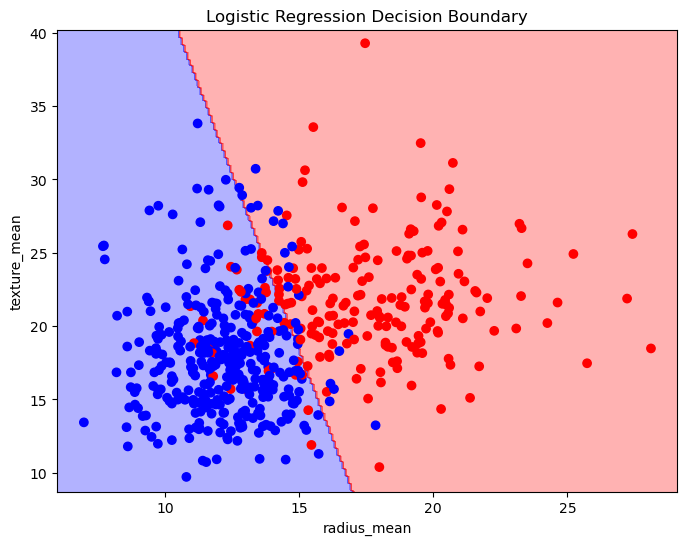

In [42]:
X = data[['radius_mean', 'texture_mean']].values
y = (data['diagnosis'] == 'M').astype(int).values

model.fit(X, y)

x1_min, x1_max = X[:,0].min()-1, X[:,0].max()+1
x2_min, x2_max = X[:,1].min()-1, X[:,1].max()+1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.1),
    np.arange(x2_min, x2_max, 0.1)
)

Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=ListedColormap(('blue', 'red')))
plt.scatter(X[:,0], X[:,1], c=y, cmap=ListedColormap(('blue', 'red')))
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("Logistic Regression Decision Boundary")
plt.show()

In [26]:
print(f"Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(report)

Model Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        71
           M       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Conclusion

Awesome work! 

You've successfully built a breast cancer prediction model using Logistic Regression. You explored the data, cleaned it, visualized it, trained a model, and evaluated its performance.
